In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [3]:
import pandas as pd
import requests
from io import StringIO

url = "https://raw.githubusercontent.com/plotly/datasets/master/heart.csv"

response = requests.get(url)

df = pd.read_csv(StringIO(response.text))

print(df.head())

Empty DataFrame
Columns: [404: Not Found]
Index: []


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 1 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   404: Not Found  0 non-null      object
dtypes: object(1)
memory usage: 132.0+ bytes


,404: Not Found
count,0
unique,0
top,NaN
freq,NaN


In [9]:
url = "https://gist.githubusercontent.com/vivek2606/88ec0800798ee7bf8540193acde83553/raw/heart.csv"
df = pd.read_csv(url)

print(df.head())

   age  sex  pain type   BP  cholestrol  fbs  resting ecg  max heart rate  \
0   70    1          4  130         322    0            2             109   
1   67    0          3  115         564    0            2             160   
2   57    1          2  124         261    0            0             141   
3   64    1          4  128         263    0            0             105   
4   74    0          2  120         269    0            2             121   

   exercise angina  ST depression  ST slope  flouroscopy coloured  thal  \
0                0            2.4         2                     3     3   
1                0            1.6         2                     0     7   
2                0            0.3         1                     0     7   
3                1            0.2         2                     1     7   
4                1            0.2         1                     1     3   

   heart disease  
0              2  
1              1  
2              2  
3         

In [14]:
print(df.columns)
print(df.head())

Index(['age', 'sex', 'pain type', 'BP', 'cholestrol', 'fbs', 'resting ecg',
       'max heart rate', 'exercise angina', 'ST depression', 'ST slope',
       'flouroscopy coloured', 'thal', 'heart disease'],
      dtype='object')
   age  sex  pain type   BP  cholestrol  fbs  resting ecg  max heart rate  \
0   70    1          4  130         322    0            2             109   
1   67    0          3  115         564    0            2             160   
2   57    1          2  124         261    0            0             141   
3   64    1          4  128         263    0            0             105   
4   74    0          2  120         269    0            2             121   

   exercise angina  ST depression  ST slope  flouroscopy coloured  thal  \
0                0            2.4         2                     3     3   
1                0            1.6         2                     0     7   
2                0            0.3         1                     0     7   
3        

In [24]:
# Split features and target variable

X = df.drop("heart disease", axis=1)
y = df["heart disease"]

In [25]:
# --- Train/test split ---

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
# Split features and target variable

X = df.drop("heart disease", axis=1)
y = df["heart disease"]

In [45]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import confusion_matrix

# Get probability predictions
y_probs = model.predict_proba(X_test)[:, 1]

# Create list of thresholds
thresholds = np.arange(0.1, 1.0, 0.1)

# Create frames for animation
frames = []
for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    
    # Normalize confusion matrix for better visualization
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    frames.append(go.Frame(
        data=[go.Heatmap(
            z=cm,
            x=['Negative', 'Positive'],
            y=['Negative', 'Positive'],
            text=cm,
            texttemplate='%{text}',
            colorscale='Blues'
        )],
        name=str(round(threshold, 1))
    ))

# Create initial heatmap
y_pred_init = (y_probs >= thresholds[0]).astype(int)
cm_init = confusion_matrix(y_test, y_pred_init)

fig = go.Figure(
    data=[go.Heatmap(
        z=cm_init,
        x=['Negative', 'Positive'],
        y=['Negative', 'Positive'],
        text=cm_init,
        texttemplate='%{text}',
        colorscale='Blues'
    )],
    frames=frames
)

fig.update_layout(
    title=f"Animated Confusion Matrix (Threshold: {thresholds[0]:.1f})",
    xaxis_title="Predicted",
    yaxis_title="Actual",
    updatemenus=[{
        'type': 'buttons',
        'showactive': False,
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 500}, 'fromcurrent': True}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]}
        ]
    }],
    sliders=[{
        'active': 0,
        'steps': [{'args': [[f.name], {'frame': {'duration': 300}, 'mode': 'immediate'}],
                  'label': f'Threshold: {f.name}', 'method': 'animate'} for f in frames],
        'transition': {'duration': 300}
    }]
)

fig.show()

C:\Users\AMIT PAUL\AppData\Local\Temp\ipykernel_25204\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\AMIT PAUL\AppData\Local\Temp\ipykernel_25204\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\AMIT PAUL\AppData\Local\Temp\ipykernel_25204\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\AMIT PAUL\AppData\Local\Temp\ipykernel_25204\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\AMIT PAUL\AppData\Local\Temp\ipykernel_25204\1370799242.py:18: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
C:\Users\AMIT PAUL\AppData\Local\Te

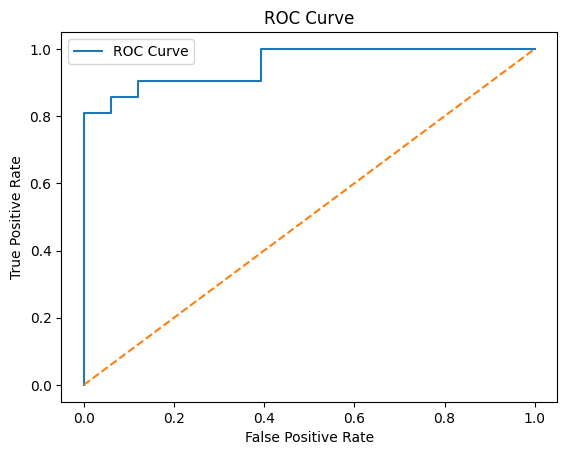

In [47]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Convert labels from {1,2} → {0,1}
y_test_binary = (y_test == 2).astype(int)

# Get probability predictions
y_probs = model.predict_proba(X_test)[:,1]

# Calculate ROC values
fpr, tpr, _ = roc_curve(y_test_binary, y_probs)

# Plot ROC Curve
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# --- Load Wine Quality dataset ---
# Dataset available at:
# https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv

url = "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv"

df = pd.read_csv(url)

print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [49]:
# Convert quality into binary classification
df["quality"] = (df["quality"] >= 7).astype(int)

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.859375
Precision: 0.55
Recall: 0.23404255319148937
F1 Score: 0.3283582089552239


In [50]:
# Load dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv"

data = pd.read_csv(url)

# Convert quality scores into binary classification
# Good wine (quality >= 7) vs Not good (quality < 7)

data["target"] = (data["quality"] >= 7).astype(int)

# Features and target
X = data.drop(["quality", "target"], axis=1)
y = data["target"]

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [52]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.859375
Precision: 0.55
Recall: 0.23404255319148937
F1 Score: 0.3283582089552239


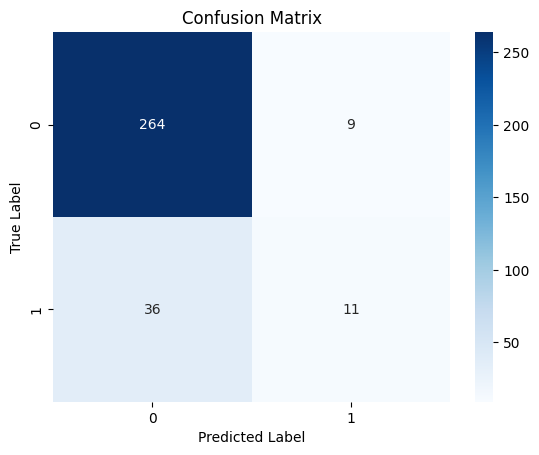

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

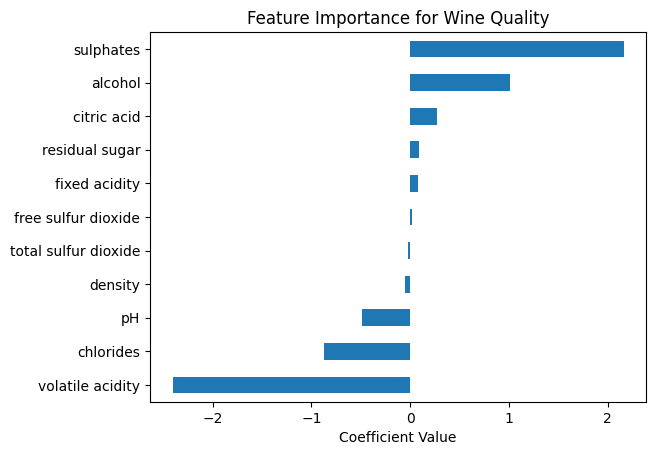

In [54]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=X.columns)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Wine Quality")
plt.xlabel("Coefficient Value")

plt.show()

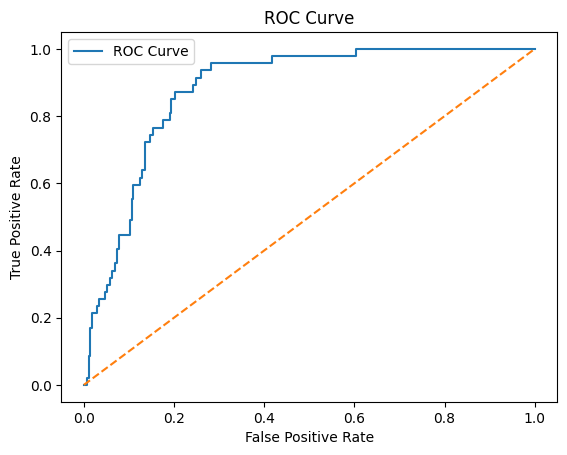

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [56]:
auc = roc_auc_score(y_test, y_probs)

print("AUC Score:", auc)

AUC Score: 0.8800561140986672


In [57]:
# Train Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluation metrics
print("Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Model Performance:
Accuracy: 0.8594
Precision: 0.5500
Recall: 0.2340
F1 Score: 0.3284

Confusion Matrix:
[[264   9]
 [ 36  11]]


In [58]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[264   9]
 [ 36  11]]


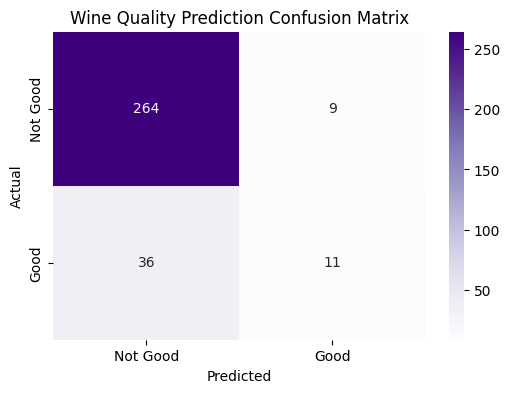

In [59]:
# --- Visual Confusion Matrix ---

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=["Not Good", "Good"],
    yticklabels=["Not Good", "Good"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Wine Quality Prediction Confusion Matrix")

plt.show()